# 02. Model Evaluation

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import get_config

CONFIG = get_config()

In [2]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import FER2013CNN
from src.data import FER2013Dataset, val_test_transform, get_dataloader

In [3]:
test_dataset = FER2013Dataset(
    split=CONFIG["data"]["test_split"],
    transform=val_test_transform
)
test_loader = get_dataloader(test_dataset)

checkpoint_cfg = CONFIG["callbacks"]["checkpoint"]
checkpoint_root = PROJECT_ROOT / checkpoint_cfg["root_dir"]
run_prefix = checkpoint_cfg["run_prefix"]
best_filename = checkpoint_cfg["best_filename"]

run_dirs = sorted(
    [path for path in checkpoint_root.glob(f"{run_prefix}*") if path.is_dir()]
)

if run_dirs:
    checkpoint_path = run_dirs[-1] / best_filename
else:
    checkpoint_path = checkpoint_root / best_filename

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

print(f"Using checkpoint: {checkpoint_path}")

Using checkpoint: /home/miguel/git/fer-2013/checkpoints/checkpoint_20260226100730/best_model.pt


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FER2013CNN(input_channels=test_dataset.input_channels)
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

FER2013CNN(
  (conv1): Conv2d(9, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4608, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=7, bias=True)
)

In [5]:
ground_truths = []
predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        ground_truths.extend(labels.cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

In [6]:
idx_to_class = {idx: cls for cls, idx in test_dataset.class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]

print(
    classification_report(
        ground_truths,
        predictions,
        target_names=class_names,
        digits=4,
    )
)

              precision    recall  f1-score   support

       angry     0.4464    0.4562    0.4512       958
     disgust     0.2812    0.7297    0.4060       111
        fear     0.4206    0.2197    0.2886      1024
       happy     0.7690    0.7525    0.7607      1774
     neutral     0.4837    0.5523    0.5157      1233
         sad     0.4115    0.3841    0.3973      1247
    surprise     0.6030    0.7750    0.6783       831

    accuracy                         0.5408      7178
   macro avg     0.4879    0.5528    0.4997      7178
weighted avg     0.5384    0.5408    0.5318      7178



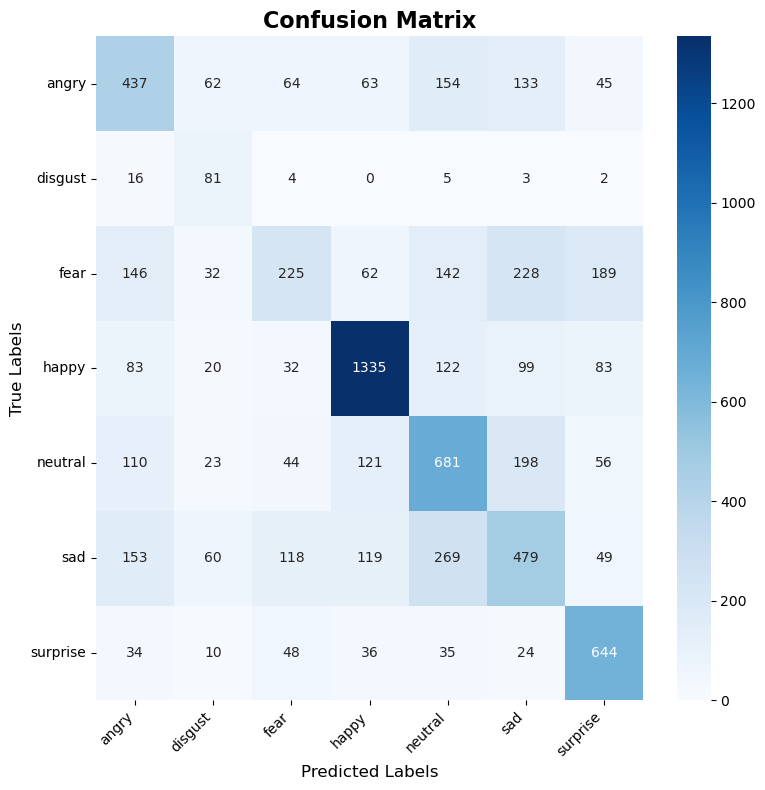

In [7]:
cm = confusion_matrix(ground_truths, predictions)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
 )

ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold")
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()